In [10]:
import networkx as nx
import pickle
import copy
import matplotlib.pyplot as plt
from epidemic_simulation.sir_simulation import fast_SIR
from epidemic_simulation.helpers import *
from sample.helpers import *
from sample.sampling_trees_MH import TreeSamplerMH
from sample.sampling_trees import feasible_tree

In [11]:
#Loading our example of verification test
with open('data/graphs/verification_test_graph.pickle', mode='rb') as f:
    G = pickle.load(f)

beta = 0.4
fast_SIR(G, [0], beta)

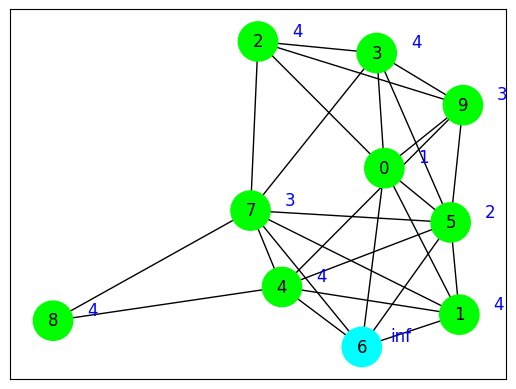

In [12]:
#Visualization of the graph with their respectives infection times
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
pos = nx.spring_layout(G, seed = 0)
state_pos = {n: (x + 0.14, y + 0.05) for n, (x,y) in pos.items()}

nx.draw_networkx(G,
                pos,
                node_size = 800,
                node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

In [13]:
#Making a copy with the real infection times
G_real = copy.deepcopy(G)

#Selecting a fraction of nodes that will not be observed.
p_excluded = 0.4
excluded, infected_nodes = excludeInfTime(G, p_excluded)

#Deleting nodes that we known were not infected from the graph.
delete_susceptibles(G)

T_initial = feasible_tree(G, infected_nodes, flag=1)

In [ ]:
if None in T_initial:
    print("Feasible tree not found!")

else:
    print(T_initial)

    samplings_number = 50

    #Initialize class
    sampler = TreeSamplerMH(G, T_initial, infected_nodes,flag=1)

    #Run
    sampling = sampler.run(n_iterations=samplings_number)
    print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
    print("--------------------------------------------------------------------------------------------")
    print(f"Frequency of nodes: {nodes_proportion(G, sampling)}")

[[0], [2, 7], [4, 9], [7, 5, 0], [8, 7], [9, 5]]


Sampling trees:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling trees:  14%|█▍        | 144/1000 [00:00<00:00, 1430.27it/s]

log-likelihood: -13.100072023200072 
log-likelihood: -10.36819998397495 
log-likelihood: -15.537372610247605 
log-likelihood: -6.701660272001602 
log-likelihood: -10.497553692655393 
log-likelihood: -12.059647866014707 
log-likelihood: -4.828566463138941 
log-likelihood: -12.785926123105032 
log-likelihood: -11.435241738612058 
log-likelihood: -9.739950967126735 
log-likelihood: -5.699266960341278 
log-likelihood: -12.315823144452288 
log-likelihood: -12.860218883706121 
log-likelihood: -9.669636807296756 
log-likelihood: -7.076593515893011 
log-likelihood: -23.332482156681593 
log-likelihood: -8.631350085028492 
log-likelihood: -17.14515932620505 
log-likelihood: -14.171476989364132 
log-likelihood: -9.118990269996115 
log-likelihood: -12.098578814672749 
log-likelihood: -14.152763321205324 
log-likelihood: -4.583992775663084 
log-likelihood: -14.418782614972676 
log-likelihood: -22.604587295784043 
log-likelihood: -9.731768169036759 
log-likelihood: -13.976040156428343 
log-likelihoo

Sampling trees:  58%|█████▊    | 584/1000 [00:00<00:00, 1232.88it/s]

log-likelihood: -12.06852932219783 
log-likelihood: -5.263274410156269 
log-likelihood: -7.721656805739544 
log-likelihood: -25.921335474387845 
log-likelihood: -11.820615662217392 
log-likelihood: -11.929054148739171 
log-likelihood: -10.247975212897797 
log-likelihood: -10.490413833515534 
log-likelihood: -13.574537886382545 
log-likelihood: -7.190193246840008 
log-likelihood: -14.716388625391328 
log-likelihood: -3.7516100249991604 
log-likelihood: -23.34505370259386 
log-likelihood: -3.829124556310291 
log-likelihood: -10.45708472091496 
log-likelihood: -10.993890694628657 
log-likelihood: -14.541717129554485 
log-likelihood: -26.452178484099715 
log-likelihood: -22.416238970432627 
log-likelihood: -8.532266679825701 
log-likelihood: -11.385462070607527 
log-likelihood: -3.604233691516169 
log-likelihood: -9.003186159350577 
log-likelihood: -11.864687158464262 
log-likelihood: -18.54077149278147 
log-likelihood: -6.910893805509838 
log-likelihood: -18.91832924064028 
log-likelihood

Sampling trees: 100%|██████████| 1000/1000 [00:00<00:00, 1368.74it/s]

log-likelihood: -8.15289704103461 
log-likelihood: -9.779501287369897 
log-likelihood: -17.989525102423414 
log-likelihood: -18.674565516511073 
log-likelihood: -22.239436865942608 
log-likelihood: -6.553691331174266 
log-likelihood: -12.089722951365763 
log-likelihood: -21.929630927019062 
log-likelihood: -8.805468776713044 
log-likelihood: -9.765446155131455 
log-likelihood: -7.581383054380399 
log-likelihood: -17.61117770458647 
log-likelihood: -9.863556225734511 
log-likelihood: -9.172991369369278 
log-likelihood: -11.294769572397358 
log-likelihood: -23.35230988576375 
log-likelihood: -10.658278715290677 
log-likelihood: -10.82924650935531 
log-likelihood: -15.503932303709139 
log-likelihood: -16.518431667200097 
log-likelihood: -16.58960920543562 
log-likelihood: -8.236659943952814 
log-likelihood: -11.593753107240948 
log-likelihood: -18.567479844674583 
log-likelihood: -6.548186381767249 
log-likelihood: -5.302681858370892 
log-likelihood: -12.48413293982452 
log-likelihood: -1

### Plots (visualizing results)
Trace plot

(The drops to low values (e.g., -40) is an indicator of bugs or an instability in the acceptance logic)

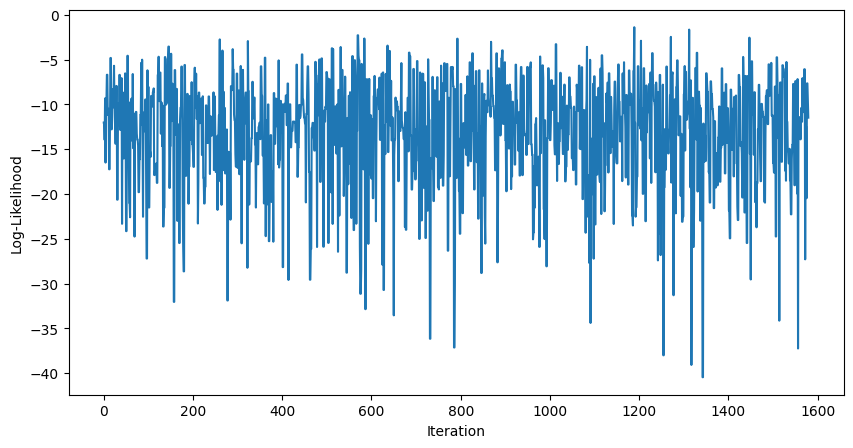

In [15]:
sampler._trace_plot_log_likelihood()